In [23]:
from pathlib import Path

import pandas as pd
import requests
from io import StringIO

# Raw URL of the file on GitHub (replace with your own file path)
raw_url = (
    "https://raw.githubusercontent.com/"
    "Ayomide-Fagbolade/ham10000-multimodal-fusion/main/outputs"
)


# Fetch the content
train_response = requests.get(f"{raw_url}/train_split.csv")
val_response = requests.get(f"{raw_url}/val_split.csv")

train_response.raise_for_status()
val_response.raise_for_status()

# Convert the CSV text into a pandas DataFrame
train_df = pd.read_csv(StringIO(train_response.text))
val_df = pd.read_csv(StringIO(val_response.text))

train_df.shape, val_df.shape

((7966, 9), (996, 9))

In [24]:
train_df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='str')

In [25]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0002615,ISIC_0033413,akiec,histo,70.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,0
1,HAM_0004139,ISIC_0027496,nv,follow_up,60.0,female,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
2,HAM_0002704,ISIC_0031638,nv,follow_up,45.0,female,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
3,HAM_0001801,ISIC_0033293,nv,histo,35.0,female,abdomen,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
4,HAM_0002947,ISIC_0031589,nv,follow_up,35.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5


columns of importance age, sex, localization

In [26]:
train_df.sex.value_counts()

sex
male       4339
female     3619
unknown       8
Name: count, dtype: int64

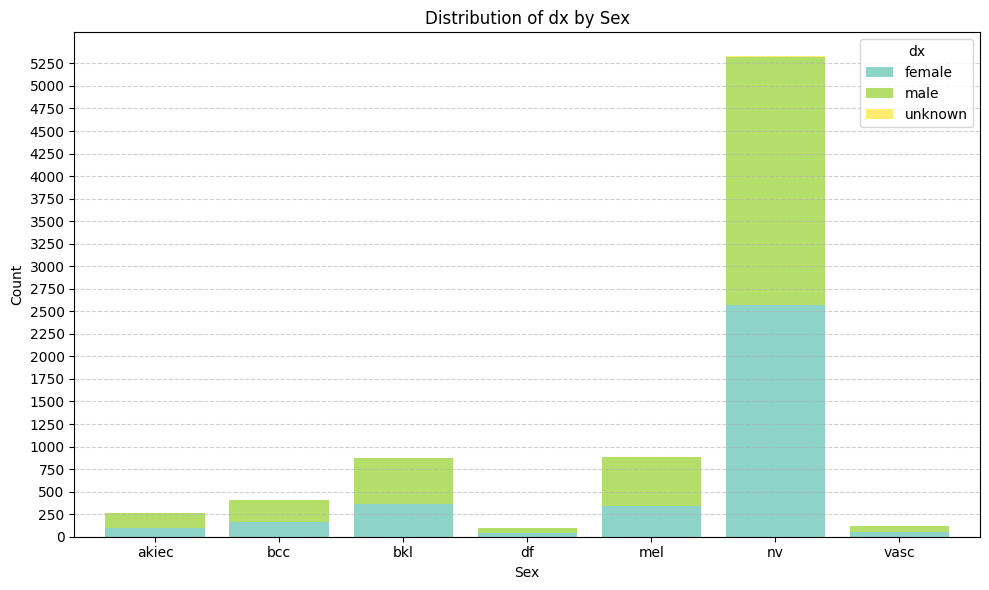

In [27]:
import matplotlib.pyplot as plt

# Count diagnoses within each sex; stacks are dx, clusters are sex
counts = train_df.groupby(["dx", "sex"]).size().unstack()

ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.8,
    colormap="Set3",
)

ax.set_title("Distribution of dx by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.set_yticks(range(0, 5500, 250))
ax.legend(title="dx")
ax.tick_params(axis="x", rotation=0)
# **Add grid lines**
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [28]:
print(counts.fillna(0).astype(int))

sex    female  male  unknown
dx                          
akiec      93   168        0
bcc       158   253        0
bkl       366   505        0
df         40    52        0
mel       337   552        0
nv       2571  2749        8
vasc       54    60        0


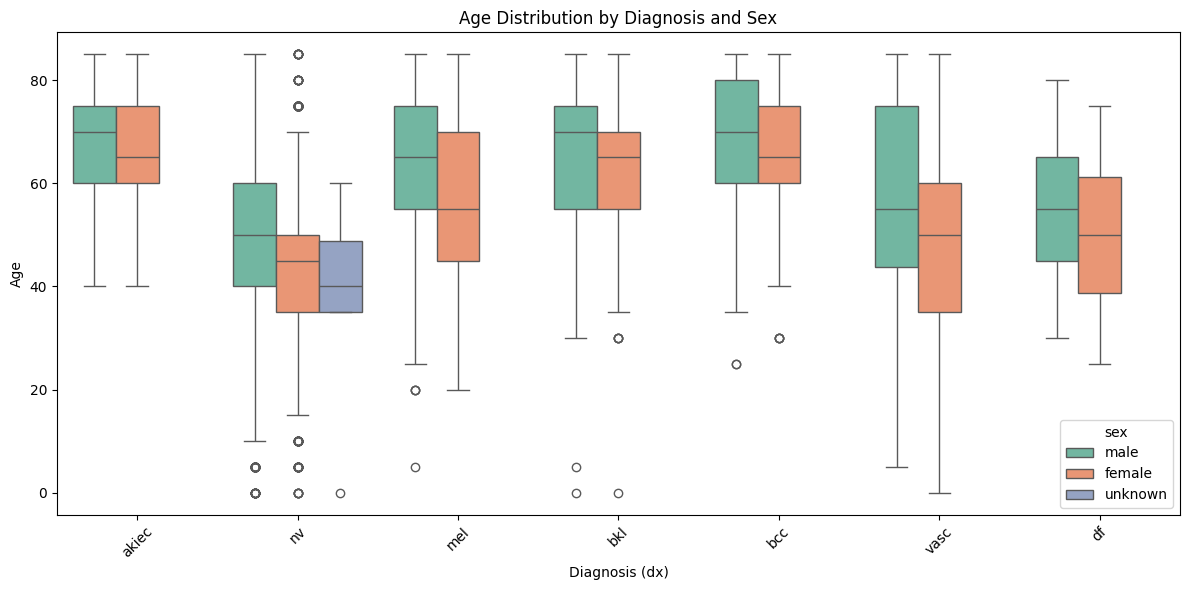

In [29]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x="dx", y="age", hue="sex", palette="Set2")
plt.title("Age Distribution by Diagnosis and Sex")
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
from pathlib import Path

fig_dir = Path("C:\\Users\\ayo\\Desktop\\ham10000-multimodal-fusion\\figures")
fig_dir.mkdir(parents=True, exist_ok=True)

ax.figure.tight_layout()
ax.figure.savefig(fig_dir / "distribution_dx_by_sex.png", dpi=300, bbox_inches="tight")

In [31]:
fig_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(fig_dir / "age_distribution_by_diagnosis_and_sex.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [32]:
test_response = requests.get(f"{raw_url}/test_split.csv")
test_response.raise_for_status()

test_df = pd.read_csv(StringIO(test_response.text))

test_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000795,ISIC_0033468,bcc,histo,80.0,female,back,/kaggle/input/datasets/kmader/skin-cancer-mnis...,1
1,HAM_0000398,ISIC_0027064,bkl,histo,60.0,female,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
2,HAM_0006723,ISIC_0026365,bkl,histo,45.0,male,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
3,HAM_0006478,ISIC_0026372,nv,histo,45.0,male,back,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
4,HAM_0003851,ISIC_0031643,bcc,histo,70.0,male,back,/kaggle/input/datasets/kmader/skin-cancer-mnis...,1


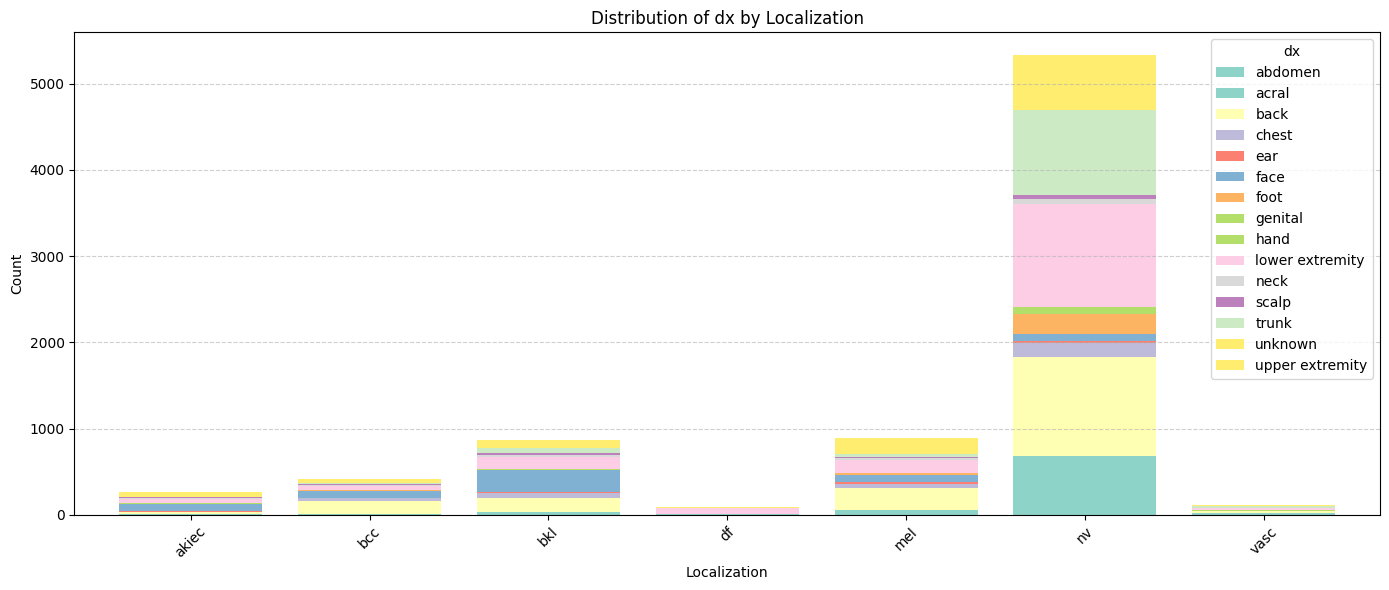

In [33]:
# Distribution of dx across localizations (stacked by dx)
localization_dx_counts = train_df.groupby(["dx", "localization"]).size().unstack(fill_value=0)

ax = localization_dx_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    width=0.8,
    colormap="Set3",
)

ax.set_title("Distribution of dx by Localization")
ax.set_xlabel("Localization")
ax.set_ylabel("Count")
ax.legend(title="dx")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [34]:
ax.figure.tight_layout()
ax.figure.savefig(fig_dir / "distribution_dx_by_localization.png", dpi=300, bbox_inches="tight")

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor(mode="passthrough"):
    """
    Build a ColumnTransformer that one-hot encodes 'sex' and 'localization',
    and either passthroughs or scales the remaining columns.

    Parameters
    ----------
    mode : {"passthrough", "scale"}
        - "passthrough": keep other columns unchanged
        - "scale": apply StandardScaler to other columns
    """
    if mode == "passthrough":
        remainder = "passthrough"
    elif mode == "scale":
        remainder = StandardScaler()
    else:
        raise ValueError("mode must be 'passthrough' or 'scale'")

    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["sex", "localization"]),
        ],
        remainder=remainder,
    )


In [36]:
train_df.label.value_counts()

label
5    5328
4     889
2     871
1     411
0     261
6     114
3      92
Name: count, dtype: int64

In [37]:
X_train=train_df[["age","sex","localization"]]
y_train=train_df["label"]

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

clf = DecisionTreeClassifier(class_weight="balanced", random_state=42)
# Build pipeline
pipeline = Pipeline([
    ("preprocessor", make_preprocessor("passthrough")),  # default
    ("classifier", clf)
])

# Define parameter grid
param_grid = {
    # Decision Tree hyperparameters
    "classifier__max_depth": [3, 5,7,9, None],
    "classifier__min_samples_split": [2, 5, 10,13,20],

    # Preprocessor mode: passthrough 
    "preprocessor": [make_preprocessor("passthrough")]
}

# Run grid search
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1_macro")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

# --- AdaBoost version ---
ada_pipeline = Pipeline([
    ("preprocessor", make_preprocessor("passthrough")),
    ("classifier", AdaBoostClassifier(random_state=42))
])

ada_param_grid = {
    "classifier__n_estimators": [50, 100, 200],

    "preprocessor": [make_preprocessor("passthrough"),
                     ]
}

ada_grid = GridSearchCV(ada_pipeline, ada_param_grid, cv=5, scoring="f1_macro")
ada_grid.fit(X_train, y_train)

print("AdaBoost best params:", ada_grid.best_params_)
print("AdaBoost best score:", ada_grid.best_score_)

xgb_pipeline = Pipeline([
    ("preprocessor", make_preprocessor("passthrough")),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=7,   # adjust to your dataset
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42
    ))
])

xgb_param_grid = {
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.3],
    "preprocessor": [make_preprocessor("passthrough"),
                    ]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring="f1_macro")
xgb_grid.fit(X_train, y_train)

print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best score:", xgb_grid.best_score_)

Best params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['sex', 'localization'])])}
Best score: 0.23401948934460406
AdaBoost best params: {'classifier__n_estimators': 200, 'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['sex', 'localization'])])}
AdaBoost best score: 0.18932807321404402


C:\Users\ayo\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [02:20:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ayo\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [02:20:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ayo\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [02:20:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ayo\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [02:20:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

XGBoost best params: {'classifier__learning_rate': 0.3, 'classifier__max_depth': 7, 'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['sex', 'localization'])])}
XGBoost best score: 0.2419303048878747


**Model tuning results (macro‑F1)**

| Model | Best hyper‑parameters | Best macro‑F1 score |
|-------|-----------------------|---------------------|
| Random Forest | `max_depth=None`, `min_samples_split=2`<br>Preprocessor: `ColumnTransformer(remainder='passthrough', transformers=[('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['sex', 'localization'])])` | **0.2340** |
| AdaBoost | `n_estimators=200`<br>Preprocessor: same as above | **0.1893** |
| XGBoost | `learning_rate=0.3`, `max_depth=7`<br>Preprocessor: same as above | **0.2419** |

*All scores are macro‑F1 values obtained from 5‑fold cross‑validation.*

Feature contributions (aggregated to original features):
original_feature
age             0.457976
localization    0.414226
sex             0.127797
Name: importance, dtype: float64

Percent of total importance:
original_feature
age             45.80
localization    41.42
sex             12.78
Name: importance, dtype: float64


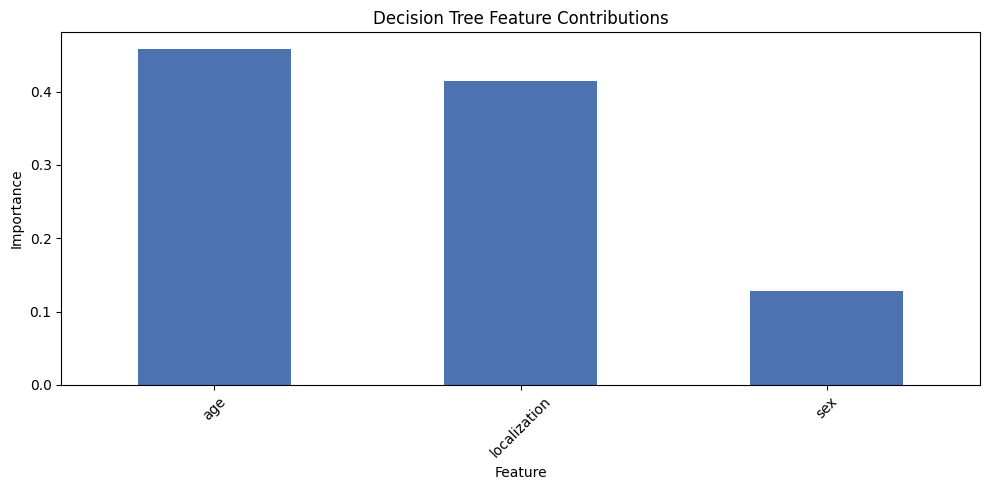

In [39]:
# Inspect feature contribution in the best decision tree
best_model = grid.best_estimator_
tree = best_model.named_steps["classifier"]
preprocessor_out = best_model.named_steps["preprocessor"]

# Get encoded feature names and their importances
encoded_feature_names = preprocessor_out.get_feature_names_out()
feature_importance_df = pd.DataFrame(
    {
        "feature": encoded_feature_names,
        "importance": tree.feature_importances_,
    }
)

# Aggregate encoded one-hot features back to the original feature names
feature_importance_df["original_feature"] = (
    feature_importance_df["feature"]
    .str.split("__", n=1)
    .str[1]
    .str.split("_", n=1)
    .str[0]
)

# Sum contributions by original feature
aggregated_importance = (
    feature_importance_df.groupby("original_feature", sort=False)["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("Feature contributions (aggregated to original features):")
print(aggregated_importance)

print("\nPercent of total importance:")
print((aggregated_importance / aggregated_importance.sum() * 100).round(2))

# Plot contributions
plt.figure(figsize=(10, 5))
aggregated_importance.plot(kind="bar", color="#4C72B0")
plt.title("Decision Tree Feature Contributions")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
fig_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(fig_dir / "decision_tree_feature_contributions.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
from sklearn.neural_network import MLPClassifier

# MLP with two hidden layers
mlp_pipeline = Pipeline([
    ("preprocessor", make_preprocessor("scale")),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(15,),   # 2 hidden layers
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
    )),
])

# Optional hyperparameter search for the MLP
mlp_param_grid = {
    "classifier__hidden_layer_sizes": [(40,20),(50,25)],
    "classifier__alpha": [0.0001, 0.001, 0.01],
}


mlp_grid = GridSearchCV(mlp_pipeline, mlp_param_grid, cv=5, scoring="f1_macro")
mlp_grid.fit(X_train, y_train)

print("MLP best params:", mlp_grid.best_params_)
print("MLP best score:", mlp_grid.best_score_)

MLP best params: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (50, 25)}
MLP best score: 0.20944175607039117
